In [1]:
# pyright: reportUnusedExpression=false

# Data Contract and EDA

Decision-layer review only; this notebook does not train models.

In [2]:
data_dir: "Path | str | None" = None
tokenizer_path: "Path | str | None" = None

In [3]:
import warnings  # noqa: E402
from pathlib import Path  # noqa: E402
from typing import Any, TypedDict, cast  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402
import yaml  # noqa: E402
from pandas.util import hash_pandas_object  # noqa: E402
from tqdm import TqdmWarning  # noqa: E402

warnings.filterwarnings("ignore", category=TqdmWarning)

PROJECT_ROOT = next(
    parent
    for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (parent / "pyproject.toml").is_file()
)

config_path = PROJECT_ROOT / "configs" / "default.yaml"
with config_path.open(encoding="utf-8") as handle:
    data_config = yaml.safe_load(handle)["data"]

with config_path.open(encoding="utf-8") as handle:
    transformer_config = yaml.safe_load(handle)["transformer"]
if data_dir is None:
    data_dir = PROJECT_ROOT / Path(data_config["train_path"]).parent
else:
    data_dir = Path(data_dir)
assert data_dir is not None
resolved_data_dir = Path(data_dir)


def require_csv(filename: str, dtypes: dict[str, str]) -> pd.DataFrame:
    path = resolved_data_dir / filename
    if not path.is_file():
        raise FileNotFoundError(f"Missing required raw input: {path}")
    return pd.read_csv(
        path,
        dtype=cast(Any, dtypes),
        encoding="ISO-8859-1",
    )


train = require_csv(
    Path(data_config["train_path"]).name,
    {
        "id": "Int32",
        "product_uid": "Int32",
        "product_title": "string",
        "search_term": "string",
        "relevance": "float32",
    },
)
test = require_csv(
    Path(data_config["test_path"]).name,
    {
        "id": "Int32",
        "product_uid": "Int32",
        "product_title": "string",
        "search_term": "string",
    },
)
product_descriptions = require_csv(
    Path(data_config["product_descriptions_path"]).name,
    {"product_uid": "Int32", "product_description": "string"},
)
attributes = require_csv(
    Path(data_config["attributes_path"]).name,
    {"product_uid": "Int32", "name": "string", "value": "string"},
)

## 0. Problem Contract

Review relevance-label availability, required raw tables, and decision boundaries.

In [4]:
problem_contract = pd.DataFrame(
    {
        "table": ["train", "test", "product_descriptions", "attributes"],
        "rows": [len(train), len(test), len(product_descriptions), len(attributes)],
        "label_available": ["relevance" in train.columns, False, False, False],
    }
)
problem_contract

,table,rows,label_available
0,train,74067,True
1,test,166693,False
2,product_descriptions,124428,False
3,attributes,2044803,False


## 1. Reproducible Setup

Resolve the project root from the current working directory and use only
relative project paths.

In [5]:
setup_evidence = {
    "project_root_name": PROJECT_ROOT.name,
    "data_dir": str(
        resolved_data_dir.relative_to(PROJECT_ROOT)
        if resolved_data_dir.is_relative_to(PROJECT_ROOT)
        else resolved_data_dir
    ),
    "configured_tokenizer": transformer_config["model_name"],
}
setup_evidence

{'project_root_name': 'Kaggle_Home_Depot_Search',
 'data_dir': 'data',
 'configured_tokenizer': 'microsoft/deberta-v3-small'}

## 2. Raw Data and Join Contract

Validate join keys and row preservation before combining train, descriptions,
and attributes.

In [6]:
required_train_columns = {
    "id",
    "product_uid",
    "search_term",
    "product_title",
    "relevance",
}
missing_train_columns = required_train_columns - set(train.columns)
if missing_train_columns:
    raise ValueError(f"train.csv is missing columns: {sorted(missing_train_columns)}")


def require_join_key(table: pd.DataFrame, table_name: str) -> None:
    if "product_uid" not in table.columns:
        raise ValueError(f"{table_name}.product_uid is required for joins.")
    if not bool(table["product_uid"].notna().all()):
        raise ValueError(f"{table_name}.product_uid must not contain null values.")


def require_unique_join_key(table: pd.DataFrame, table_name: str) -> None:
    require_join_key(table, table_name)
    if bool(table["product_uid"].duplicated().any()):
        raise ValueError(
            f"{table_name}.product_uid must be unique before joining; "
            "deduplicate or aggregate the table first."
        )


require_join_key(train, "train")
require_unique_join_key(product_descriptions, "product_descriptions")
attributes_join = (
    attributes.fillna({"name": "", "value": ""})
    .assign(attribute=lambda frame: frame["name"] + "=" + frame["value"])
    .groupby("product_uid", as_index=False)["attribute"]
    .agg(" | ".join)
    .rename(columns={"attribute": "attributes"})  # type: ignore[call-overload]
)
brand_join = (
    attributes.loc[
        attributes["name"].fillna("").str.casefold().eq("mfg brand name"),
        ["product_uid", "value"],
    ]
    .drop_duplicates("product_uid")
    .rename(columns={"value": "brand"})
)
require_unique_join_key(attributes_join, "attributes")
require_unique_join_key(brand_join, "brand")

joined_train = train.merge(
    product_descriptions, on="product_uid", how="left", validate="many_to_one"
)
if len(joined_train) != len(train):
    raise ValueError("Joining product_descriptions changed the train row count.")
joined_train = joined_train.merge(
    attributes_join, on="product_uid", how="left", validate="many_to_one"
)
if len(joined_train) != len(train):
    raise ValueError("Joining attributes changed the train row count.")
joined_train = joined_train.merge(
    brand_join, on="product_uid", how="left", validate="many_to_one"
)
if len(joined_train) != len(train):
    raise ValueError("Joining brand attributes changed the train row count.")

join_contract = pd.DataFrame(
    [
        {
            "table": "product_descriptions",
            "key": "product_uid",
            "key_unique": product_descriptions["product_uid"].is_unique,
            "rows_before": len(train),
            "rows_after": len(
                train.merge(product_descriptions, on="product_uid", how="left")
            ),
        },
        {
            "table": "attributes",
            "key": "product_uid",
            "key_unique": attributes_join["product_uid"].is_unique,
            "rows_before": len(train),
            "rows_after": len(joined_train),
        },
    ]
)
join_contract

,table,key,key_unique,rows_before,rows_after
0,product_descriptions,product_uid,True,74067,74067
1,attributes,product_uid,True,74067,74067


### Observation
The raw contract contains 74,067 labeled train rows, 166,693 unlabeled test
rows, 124,428 product descriptions, and 2,044,803 attribute rows. Both
product-description and aggregated-attribute joins use unique `product_uid`
keys and preserve all 74,067 train rows.

### Interpretation
The required source tables are available, and the current many-to-one joins
do not multiply or drop training examples.

### Action
Keep the validated left joins and their row-count checks as prerequisites for
every feature-building run.

## 3. Target and Text-Field Audit

Audit target range and null or empty text fields without changing raw values.

In [7]:
text_columns = ["search_term", "product_title"]
target_audit = train["relevance"].describe().to_frame(name="relevance")
text_audit = pd.DataFrame(
    {
        "null_count": train[text_columns].isna().sum(),
        "empty_count": train[text_columns].fillna("").eq("").sum(),
    }
)
target_audit, text_audit

(          relevance
 count  74067.000000
 mean       2.381634
 std        0.533984
 min        1.000000
 25%        2.000000
 50%        2.330000
 75%        3.000000
 max        3.000000,
                null_count  empty_count
 search_term             0            0
 product_title           0            0)

Visualize the discrete relevance-score distribution to see which label
values concentrate the mass.

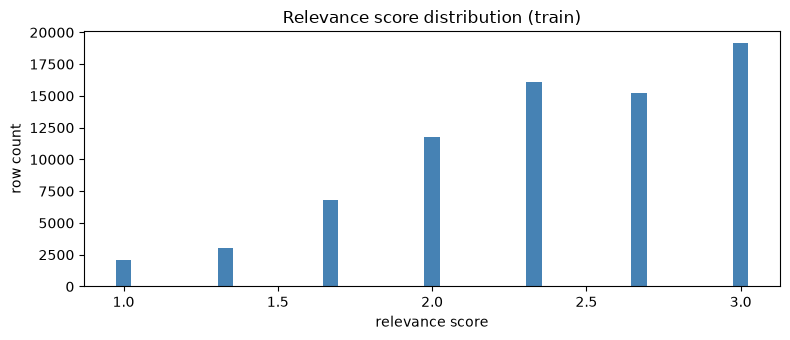

In [8]:
relevance_counts = (
    train["relevance"].value_counts().sort_index().rename_axis("relevance")
)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(
    relevance_counts.index.astype("float64"),
    relevance_counts.to_numpy(),
    width=0.05,
    color="steelblue",
)
ax.set_xlabel("relevance score")
ax.set_ylabel("row count")
ax.set_title("Relevance score distribution (train)")
fig.tight_layout()
plt.show()

### Observation
Relevance spans 1.00 to 3.00 across 74,067 rows, with mean 2.381634,
median 2.33, and standard deviation 0.533984. `search_term` and
`product_title` each have zero null and zero empty values.

### Interpretation
The supervised target is within the competition range, and the two required
query/title fields need no missing-text imputation for this dataset version.

### Action
Retain the raw target and text values, enforce the observed 1.00--3.00 target
range at data-load time, and avoid adding empty-text fallback features.

## 4. Text Quality and Length Profiling

Profile text length and whitespace-token length to set later tokenizer and
preprocessing decisions.

In [9]:
text_profile = pd.DataFrame(
    {
        column: {
            "characters_p50": train[column].fillna("").str.len().quantile(0.5),
            "characters_p99": train[column].fillna("").str.len().quantile(0.99),
            "tokens_p99": (
                train[column].fillna("").str.split().str.len().quantile(0.99)
            ),
        }
        for column in text_columns
    }
).T
text_profile

,characters_p50,characters_p99,tokens_p99
search_term,18.0,41.0,7.0
product_title,67.0,128.0,23.0


Visualize character and whitespace-token length distributions for both
mandatory text fields; dashed lines mark the p99 quantiles from the table
above.

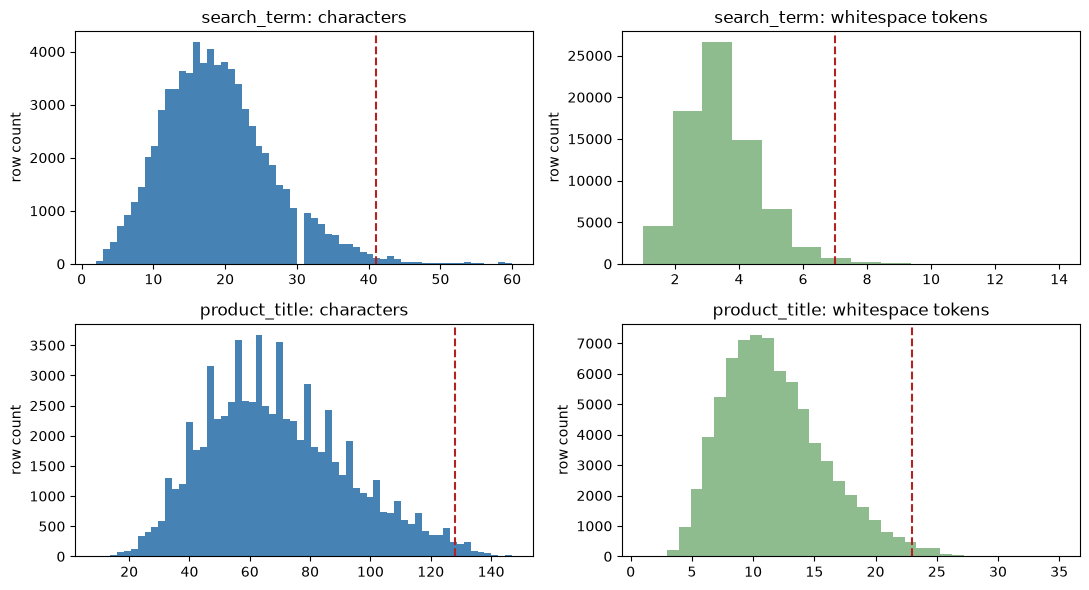

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for row, column in enumerate(text_columns):
    characters = train[column].fillna("").str.len()
    tokens = train[column].fillna("").str.split().str.len()
    axes[row, 0].hist(characters, bins=60, color="steelblue")
    axes[row, 0].axvline(
        float(characters.quantile(0.99)), color="firebrick", linestyle="--"
    )
    axes[row, 0].set_title(f"{column}: characters")
    axes[row, 1].hist(tokens, bins=tokens.max() or 1, color="darkseagreen")
    axes[row, 1].axvline(
        float(tokens.quantile(0.99)), color="firebrick", linestyle="--"
    )
    axes[row, 1].set_title(f"{column}: whitespace tokens")
for ax in axes.ravel():
    ax.set_ylabel("row count")
fig.tight_layout()
plt.show()

Relate query length to the target: mean relevance per query token count
shows whether longer queries shift the label distribution.

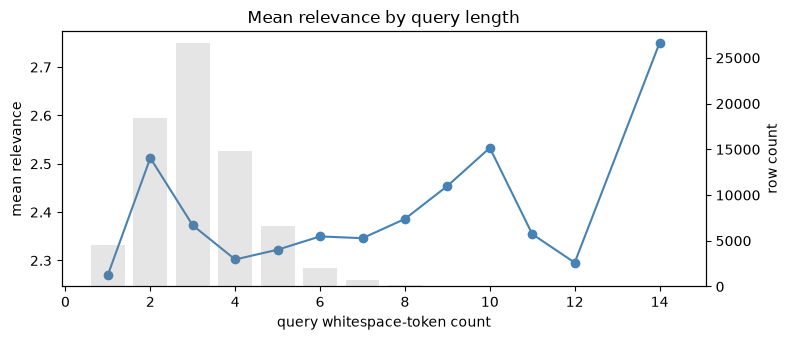

In [11]:
query_tokens = train["search_term"].fillna("").str.split().str.len()
length_vs_relevance = (
    pd.DataFrame(
        {"query_tokens": query_tokens, "relevance": train["relevance"]}
    )
    .groupby("query_tokens")["relevance"]
    .agg(["mean", "count"])
)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(
    length_vs_relevance.index,
    length_vs_relevance["mean"],
    marker="o",
    color="steelblue",
)
ax.set_xlabel("query whitespace-token count")
ax.set_ylabel("mean relevance")
ax.set_title("Mean relevance by query length")
ax_count = ax.twinx()
ax_count.bar(
    length_vs_relevance.index,
    length_vs_relevance["count"],
    alpha=0.2,
    color="gray",
)
ax_count.set_ylabel("row count")
fig.tight_layout()
plt.show()

### Observation
`search_term` has p50/p99 lengths of 18/41 characters and 7 whitespace
tokens at p99. `product_title` has p50/p99 lengths of 67/128 characters and
23 whitespace tokens at p99.

### Interpretation
Queries are short relative to titles; title text is the longer mandatory
field, but both fields have modest observed whitespace-token lengths.

### Action
Preserve both fields in classical text features and use these distributions as
the baseline when evaluating later tokenizer-length evidence.

## 5. Duplicate, Near-Duplicate, and Leakage Audit

Use normalized exact-text and row-hash evidence to flag possible leakage for
later split decisions.

In [12]:
normalized_text = (
    train[text_columns]
    .fillna("")
    .apply(
        lambda column: (
            column.str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
        )
    )
)
normalized_hash: pd.Series = cast(
    pd.Series,
    hash_pandas_object(normalized_text, index=False),  # type: ignore[call-arg]
)
duplicate_audit = pd.DataFrame(
    {
        "normalized_exact_duplicate_rows": [
            int(cast(int, normalized_text.duplicated().sum()))
        ],
        "normalized_hash_duplicate_rows": [
            int(cast(int, normalized_hash.duplicated().sum()))
        ],
        "id_overlap_train_test": [int(cast(int, train["id"].isin(test["id"]).sum()))],
    }
)
duplicate_audit

,normalized_exact_duplicate_rows,normalized_hash_duplicate_rows,id_overlap_train_test
0,692,692,0


Visualize the duplicate and leakage audit counts against total train rows to
keep their magnitude in perspective.

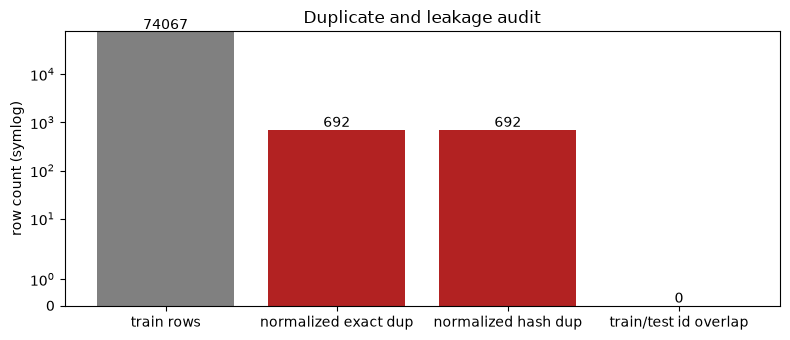

In [13]:
audit_bars = pd.Series(
    {
        "train rows": len(train),
        "normalized exact dup": int(
            duplicate_audit.loc[0, "normalized_exact_duplicate_rows"]
        ),
        "normalized hash dup": int(
            duplicate_audit.loc[0, "normalized_hash_duplicate_rows"]
        ),
        "train/test id overlap": int(duplicate_audit.loc[0, "id_overlap_train_test"]),
    }
)
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(
    audit_bars.index,
    audit_bars.to_numpy(),
    color=["gray", "firebrick", "firebrick", "darkorange"],
)
ax.bar_label(bars, fmt="%d")
ax.set_yscale("symlog")
ax.set_ylabel("row count (symlog)")
ax.set_title("Duplicate and leakage audit")
fig.tight_layout()
plt.show()

### Observation
Normalized query/title text identifies 692 exact-duplicate rows, and the
corresponding row-hash audit also identifies 692 duplicates. Train and test
IDs have zero overlap.

### Interpretation
Exact duplicate text pairs are present within training data, while the ID
audit does not indicate direct train/test identifier leakage.

### Action
Audit the 692 duplicate text pairs across validation folds before accepting
model scores, and keep the zero train/test ID-overlap check in split reviews.

## 6. Query/Product Dependency and CV Decision

Measure repeated search terms and products; select a fold strategy later only
from observed dependence.

In [14]:
dependency_audit = pd.DataFrame(
    {
        "unique_search_terms": [train["search_term"].nunique(dropna=False)],
        "repeated_search_term_rows": [
            int(train["search_term"].duplicated(keep=False).sum())
        ],
        "unique_products": [train["product_uid"].nunique(dropna=False)],
        "repeated_product_rows": [
            int(train["product_uid"].duplicated(keep=False).sum())
        ],
    }
)
dependency_audit

,unique_search_terms,repeated_search_term_rows,unique_products,repeated_product_rows
0,11795,72668,54667,31302


Visualize how many rows each search term and product contributes; heavy
repetition motivates grouped validation folds.

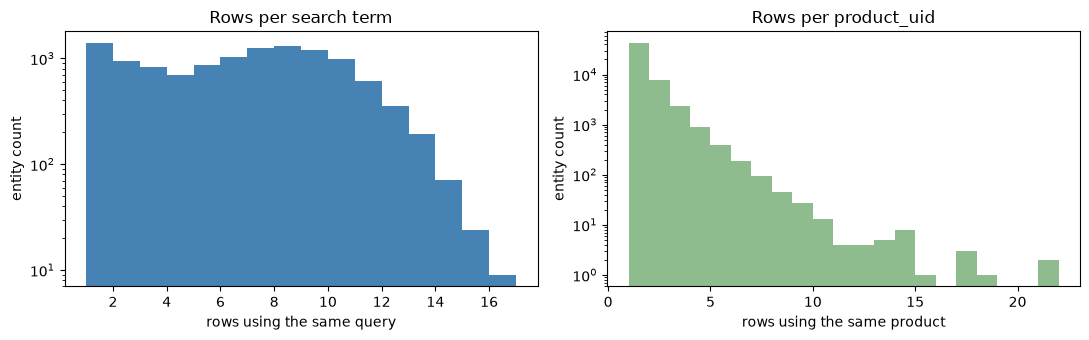

In [15]:
rows_per_query = train["search_term"].value_counts()
rows_per_product = train["product_uid"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(
    rows_per_query,
    bins=range(1, int(rows_per_query.max()) + 2),
    color="steelblue",
)
axes[0].set_title("Rows per search term")
axes[0].set_xlabel("rows using the same query")
axes[1].hist(
    rows_per_product,
    bins=range(1, int(rows_per_product.max()) + 2),
    color="darkseagreen",
)
axes[1].set_title("Rows per product_uid")
axes[1].set_xlabel("rows using the same product")
for ax in axes:
    ax.set_ylabel("entity count")
    ax.set_yscale("log")
fig.tight_layout()
plt.show()

### Observation
The 74,067 training rows contain 11,795 unique search terms; 72,668 rows use
a search term that occurs more than once. They also contain 54,667 unique
products, with 31,302 rows belonging to repeated products.

### Interpretation
Query and product observations are not independent, so a random row split can
place repeated entities on both sides of validation.

### Action
Compare query-grouped and product-grouped validation with a fixed holdout,
and report entity overlap before selecting the cross-validation strategy.

## 7. TF-IDF and DeBERTa Tokenizer Readiness

Measure local DeBERTa tokenizer lengths for combined title, description,
brand, and attributes. A missing local tokenizer is explicitly reported
instead of downloading one.

In [16]:
combined_text = (
    joined_train[["product_title", "product_description", "brand", "attributes"]]
    .fillna("")
    .astype("string")
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [17]:


class TokenizerReadiness(TypedDict):
    diagnostics: list[str]
    tokenizer_length_percentiles: pd.DataFrame
    truncation_metrics: pd.DataFrame
    token_lengths: "pd.Series[int]"


def build_tokenizer_readiness(
    combined_text: pd.Series,
    tokenizer_reference: str | Path,
    tokenizer_loader: Any = None,
) -> TokenizerReadiness:
    import contextlib
    import io
    import re

    diagnostics: list[str] = []
    try:
        if tokenizer_loader is None:
            transformers = __import__("transformers")
            transformers.logging.set_verbosity(transformers.logging.CRITICAL)
            tokenizer_loader = transformers.AutoTokenizer.from_pretrained
        with (
            contextlib.redirect_stdout(io.StringIO()),
            contextlib.redirect_stderr(io.StringIO()),
        ):
            tokenizer = tokenizer_loader(tokenizer_reference, local_files_only=True)
    except (ImportError, OSError, ValueError) as error:
        error_text = re.sub(r"/(?:[\w.@+-]+/)+", ".../", str(error))
        diagnostics.append(
            "needs-new-evidence: local DeBERTa tokenizer is unavailable for "
            f"{tokenizer_reference!r}: {error_text}"
        )
        return {
            "diagnostics": diagnostics,
            "tokenizer_length_percentiles": pd.DataFrame(),
            "truncation_metrics": pd.DataFrame(),
            "token_lengths": pd.Series(name="token_length", dtype="int64"),
        }

    token_lengths = pd.Series(
        [
            len(token_ids)
            for token_ids in tokenizer(
                combined_text.tolist(),
                add_special_tokens=True,
                truncation=False,
                padding=False,
            )["input_ids"]
        ],
        name="token_length",
    )
    tokenizer_length_percentiles = (
        token_lengths.quantile([0.5, 0.9, 0.95, 0.99, 1.0])
        .rename_axis("percentile")
        .reset_index(name="token_length")
    )
    truncation_metrics = pd.DataFrame(
        [
            {
                "max_length": max_length,
                "truncation_count": int(token_lengths.gt(max_length).sum()),
                "truncation_rate": float(token_lengths.gt(max_length).mean()),
            }
            for max_length in (128, 256, 512)
        ]
    )
    return {
        "diagnostics": diagnostics,
        "tokenizer_length_percentiles": tokenizer_length_percentiles,
        "truncation_metrics": truncation_metrics,
        "token_lengths": token_lengths,
    }

In [18]:
tokenizer_reference = tokenizer_path or transformer_config["model_name"]
tokenizer_readiness = build_tokenizer_readiness(combined_text, tokenizer_reference)
tokenizer_diagnostics = tokenizer_readiness["diagnostics"]
tokenizer_length_percentiles = tokenizer_readiness["tokenizer_length_percentiles"]
truncation_metrics = tokenizer_readiness["truncation_metrics"]
if tokenizer_diagnostics:
    print(*tokenizer_diagnostics, sep="\n")
tokenizer_length_percentiles, truncation_metrics

(   percentile  token_length
 0        0.50        355.00
 1        0.90        710.00
 2        0.95        851.00
 3        0.99       1272.34
 4        1.00       3721.00,
    max_length  truncation_count  truncation_rate
 0         128             68524         0.925162
 1         256             53316         0.719835
 2         512             18242         0.246291)

Visualize the DeBERTa token-length distribution with candidate `max_length`
cutoffs; if the tokenizer is unavailable, fall back to whitespace-token
lengths so a distribution shape is still on record.

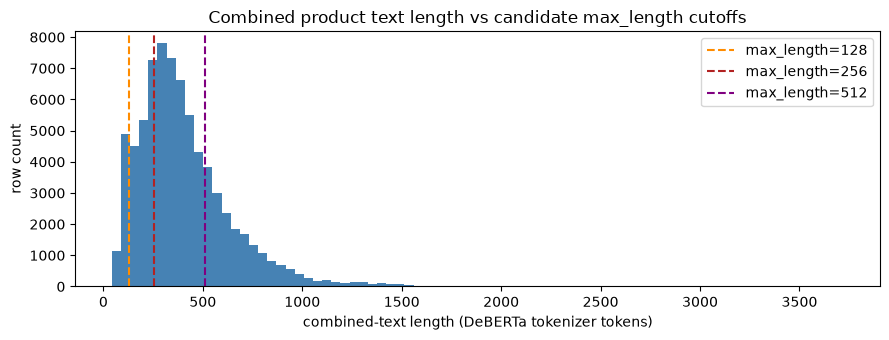

In [19]:
token_lengths = tokenizer_readiness["token_lengths"]
if token_lengths.empty:
    token_lengths = combined_text.str.split().str.len().rename("token_length")
    length_source = "whitespace tokens (fallback: no local DeBERTa tokenizer)"
else:
    length_source = "DeBERTa tokenizer tokens"
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(token_lengths, bins=80, color="steelblue")
for max_length, color in ((128, "darkorange"), (256, "firebrick"), (512, "purple")):
    ax.axvline(
        max_length, color=color, linestyle="--", label=f"max_length={max_length}"
    )
ax.set_xlabel(f"combined-text length ({length_source})")
ax.set_ylabel("row count")
ax.set_title("Combined product text length vs candidate max_length cutoffs")
ax.legend()
fig.tight_layout()
plt.show()

### Observation
The local `microsoft/deberta-v3-small` tokenizer loaded successfully and
produced token lengths for all 74,067 combined-text rows: p50/p90/p95/p99
lengths of 355/710/851/1272 tokens and a maximum of 3721. Truncation rates
are 92.52% at `max_length=128`, 71.98% at 256, and 24.63% at 512.

### Interpretation
Combined title + description + brand + attribute text is long relative to
common DeBERTa sequence lengths: 128 or 256 tokens would discard most of the
input for the large majority of rows, and even 512 tokens truncates roughly
one row in four.

### Action
Configure DeBERTa fine-tuning with `max_length=512` as the default, accept
the observed 24.63% truncation rate, and record it as a known evidence
limitation for any row where the truncated span cuts before the query-
relevant description or attribute content.

## 8. Evidence-Based Preprocessing Contract

Document transformations only after the preceding audits justify them;
preserve raw text for reproducibility.

In [20]:
preprocessing_contract = {
    "preserve_raw_text": True,
    "fit_vectorizer_on_training_fold_only": True,
    "fit_scalers_on_training_fold_only": True,
    "tokenizer_truncation_evidence": (
        "available" if not tokenizer_diagnostics else tokenizer_diagnostics[0]
    ),
}
preprocessing_contract

{'preserve_raw_text': True,
 'fit_vectorizer_on_training_fold_only': True,
 'fit_scalers_on_training_fold_only': True,
 'tokenizer_truncation_evidence': 'available'}

### Observation
Raw text is preserved, and vectorizers and scalers are configured to fit only
on each training fold. The audit found 692 normalized duplicate text pairs,
72,668 rows with repeated queries, and 31,302 rows with repeated products;
tokenizer truncation evidence is now available (24.63% truncation at
`max_length=512`, per section 7).

### Interpretation
Fold-local preprocessing is necessary to avoid leakage from repeated text and
entities, and the DeBERTa truncation rate is now a resolved, evidence-backed
configuration input rather than an open question.

### Action
Keep raw text immutable, fit all learned preprocessing inside each training
fold, include duplicate/entity-overlap checks in validation, and use
`max_length=512` for DeBERTa fine-tuning per the section 7 evidence.

## 9. Findings and Next Actions

Record unresolved data risks and the evidence required before model experimentation.

In [21]:
findings_and_next_actions = pd.DataFrame(
    {
        "evidence": [
            "join_contract",
            "text_profile",
            "duplicate_audit",
            "dependency_audit",
            "tokenizer_readiness",
        ],
        "state": [
            "available",
            "available",
            "available",
            "available",
            "available" if not tokenizer_diagnostics else tokenizer_diagnostics[0],
        ],
    }
)
findings_and_next_actions

,evidence,state
0,join_contract,available
1,text_profile,available
2,duplicate_audit,available
3,dependency_audit,available
4,tokenizer_readiness,available
